# 01 — Exploration du jeu de données

**Projet Air Paradis — prédiction du sentiment d'un tweet**

---

## Objectif de ce notebook

Ce notebook est le **point de départ obligatoire** du projet. Il remplit deux rôles :

1. **Comprendre les données** avant de modéliser quoi que ce soit. On ne choisit pas une
   architecture de modèle au hasard : la longueur des tweets, l'équilibre des classes et le
   vocabulaire employé déterminent directement les paramètres des modèles suivants.

2. **Produire le fichier de travail partagé.** Le nettoyage des 1,6 million de tweets est fait
   ici, une seule fois, et sauvegardé sur le disque. Les trois notebooks de modélisation
   repartent tous de ce même fichier — c'est ce qui rend la comparaison des trois approches
   honnête.

> **À exécuter avant les notebooks 02, 03 et 04.**

## 1. Préparation de l'environnement

In [1]:
# ---------------------------------------------------------------------------
# Rendre le package src/ importable depuis le notebook.
#
# Un notebook s'exécute depuis le dossier notebooks/, alors que le code partagé
# se trouve dans src/, un dossier au-dessus. On remonte donc l'arborescence
# jusqu'à trouver la racine du projet (repérée par la présence de pytest.ini),
# puis on l'ajoute au chemin de recherche de Python.
#
# On procède ainsi plutôt qu'avec un ".." écrit en dur : le notebook fonctionne
# alors quel que soit l'endroit d'où Jupyter a été lancé.
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

RACINE_PROJET = next(
    dossier
    for dossier in [Path.cwd(), *Path.cwd().parents]
    if (dossier / "pytest.ini").exists()
)

if str(RACINE_PROJET) not in sys.path:
    sys.path.insert(0, str(RACINE_PROJET))

print(f"Racine du projet : {RACINE_PROJET}")

Racine du projet : C:\Users\dwyts\Documents\PROJET7 Openclassrooms


In [2]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import config
from src.data_loader import charger_donnees_brutes, formater_nombre, preparer_donnees
from src.preprocessing import nettoyer_tweet, retirer_mots_vides

# Réglages d'affichage : graphiques lisibles et colonnes de texte non tronquées.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 120)

print("Bibliothèques chargées.")

Bibliothèques chargées.


## 2. Chargement des données brutes

Le jeu de données **Sentiment140** rassemble 1 600 000 tweets en anglais collectés en 2009.

Son étiquetage est *automatique* : un tweet contenant une émoticône souriante a été classé
positif, un tweet contenant une émoticône triste a été classé négatif. Les émoticônes ont
ensuite été retirées du texte, pour que le modèle ne puisse pas « tricher » en les repérant.

Cette méthode d'étiquetage a une conséquence importante à garder en tête pour toute la suite :
**les étiquettes sont bruitées**. Un tweet ironique accompagné d'un smiley sera étiqueté
positif à tort. C'est une limite structurelle du jeu de données, et elle impose un plafond de
performance qu'aucun modèle ne pourra franchir.

In [3]:
donnees_brutes = charger_donnees_brutes()

Lecture de : training.1600000.processed.noemoticon.csv


  1 600 000 tweets charges
  Negatifs : 800 000
  Positifs : 800 000


In [4]:
donnees_brutes.head(10)

,texte,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",0
1,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,0
2,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",0
5,@Kwesidei not the whole crew,0
6,Need a hug,0
7,"@LOLTrish hey long time no see! Yes.. Rains a bit ,only a bit LOL , I'm fine thanks , how's you ?",0
8,@Tatiana_K nope they didn't have it,0
9,@twittera que me muera ?,0


## 3. Qualité et équilibre du jeu de données

Deux vérifications de routine avant toute modélisation :

- **Valeurs manquantes** — un texte vide fausserait l'entraînement.
- **Équilibre des classes** — si une classe dominait, l'exactitude (*accuracy*) deviendrait
  une métrique trompeuse et il faudrait rééquilibrer.

*(La question des doublons est traitée en section 6, après le nettoyage : c'est à ce
moment-là qu'elle devient réellement visible.)*

In [5]:
print("Valeurs manquantes par colonne :")
print(donnees_brutes.isna().sum())

Valeurs manquantes par colonne :
texte    0
label    0
dtype: int64


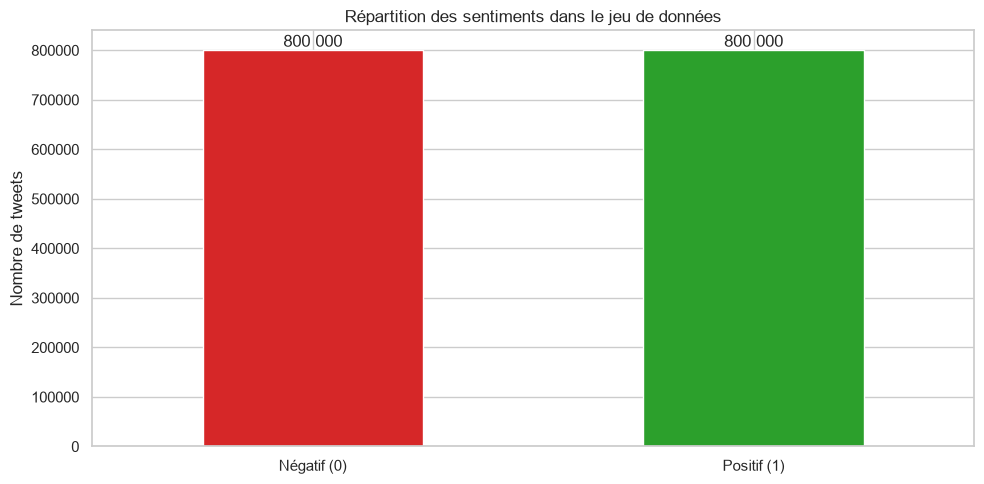

Négatif (0)    800000
Positif (1)    800000
Name: count, dtype: int64


In [6]:
repartition = donnees_brutes["label"].value_counts().sort_index()
repartition.index = ["Négatif (0)", "Positif (1)"]

axe = repartition.plot(kind="bar", color=["#d62728", "#2ca02c"], rot=0)
axe.set_title("Répartition des sentiments dans le jeu de données")
axe.set_ylabel("Nombre de tweets")

# Afficher la valeur exacte au-dessus de chaque barre.
for index, valeur in enumerate(repartition):
    axe.text(index, valeur, formater_nombre(valeur), ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(repartition)

### Ce qu'on retient

Le jeu de données est **parfaitement équilibré** : 800 000 tweets de chaque classe.

Deux conséquences pratiques :

- L'**exactitude** (*accuracy*) est une métrique fiable ici. Sur un jeu déséquilibré, un
  modèle qui répondrait toujours « positif » obtiendrait un bon score sans rien apprendre ;
  ce piège n'existe pas ici.
- Le **hasard** correspond à 50 %. C'est le point de comparaison minimal : tout modèle doit
  faire nettement mieux pour avoir un intérêt.

On suivra malgré tout plusieurs métriques (précision, rappel, F1, AUC), car le besoin
métier n'est pas symétrique : pour Air Paradis, **rater un tweet négatif** (un bad buzz qui
démarre) coûte bien plus cher que signaler à tort un tweet neutre.

## 4. Échantillon d'analyse

Les sections qui suivent examinent le texte **après nettoyage**, car c'est cela que le modèle
verra réellement — et non le texte brut, qui contient encore les liens et les mentions.

Nettoyer les 1,6 million de tweets prend une minute. Pour l'exploration, un échantillon
aléatoire de 200 000 tweets suffit largement : les proportions observées sur cet échantillon
sont fiables à moins de 0,3 % près. Le nettoyage complet, lui, sera fait une seule fois en
section 8.

In [7]:
TAILLE_ECHANTILLON_ANALYSE = 200_000

echantillon = donnees_brutes.sample(
    TAILLE_ECHANTILLON_ANALYSE,
    random_state=config.GRAINE_ALEATOIRE,
).copy()

echantillon["texte_nettoye"] = echantillon["texte"].apply(nettoyer_tweet)

print(f"Échantillon d'analyse : {formater_nombre(len(echantillon))} tweets nettoyés")

Échantillon d'analyse : 200 000 tweets nettoyés


## 5. Longueur des tweets

Cette mesure n'est pas décorative : elle fixe directement un paramètre du modèle avancé,
`LONGUEUR_MAX_SEQUENCE`.

Un réseau de neurones récurrent traite des séquences de **longueur fixe**. Il faut donc
choisir un nombre de mots :

- **trop court** → les tweets longs sont tronqués, on perd de l'information ;
- **trop long** → la majorité des séquences est remplie de zéros inutiles, et le temps de
  calcul augmente en pure perte, puisque le coût d'un réseau récurrent est *proportionnel* à
  cette longueur.

On compare volontairement le texte brut et le texte nettoyé : c'est le second qui doit
servir de référence.

In [8]:
longueur_brute = echantillon["texte"].str.split().str.len()
longueur_nettoyee = echantillon["texte_nettoye"].str.split().str.len()

print("Longueur en nombre de mots :\n")
print(f"{'Quantile':>10} | {'Texte brut':>12} | {'Texte nettoyé':>14}")
print("-" * 42)
for quantile in [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]:
    print(
        f"{quantile:>9.1%} | "
        f"{longueur_brute.quantile(quantile):>12.0f} | "
        f"{longueur_nettoyee.quantile(quantile):>14.0f}"
    )
print("-" * 42)
print(f"{'maximum':>10} | {longueur_brute.max():>12.0f} | {longueur_nettoyee.max():>14.0f}")

Longueur en nombre de mots :

  Quantile |   Texte brut |  Texte nettoyé
------------------------------------------
    50.0% |           12 |             12
    75.0% |           19 |             18
    90.0% |           23 |             23
    95.0% |           25 |             25
    99.0% |           28 |             28
    99.9% |           31 |             30
------------------------------------------
   maximum |           41 |             46


In [9]:
# Quelle couverture obtient-on selon le seuil retenu ?
print("Part des tweets nettoyés intégralement conservés, selon le seuil :\n")
for seuil in [24, 28, 32, 40, 48]:
    couverture = (longueur_nettoyee <= seuil).mean()
    marque = "  <- valeur retenue" if seuil == config.LONGUEUR_MAX_SEQUENCE else ""
    print(f"  seuil {seuil:3d} mots  ->  {couverture:8.3%}{marque}")

Part des tweets nettoyés intégralement conservés, selon le seuil :

  seuil  24 mots  ->   94.473%
  seuil  28 mots  ->   99.484%
  seuil  32 mots  ->   99.984%  <- valeur retenue
  seuil  40 mots  ->   99.999%
  seuil  48 mots  ->  100.000%


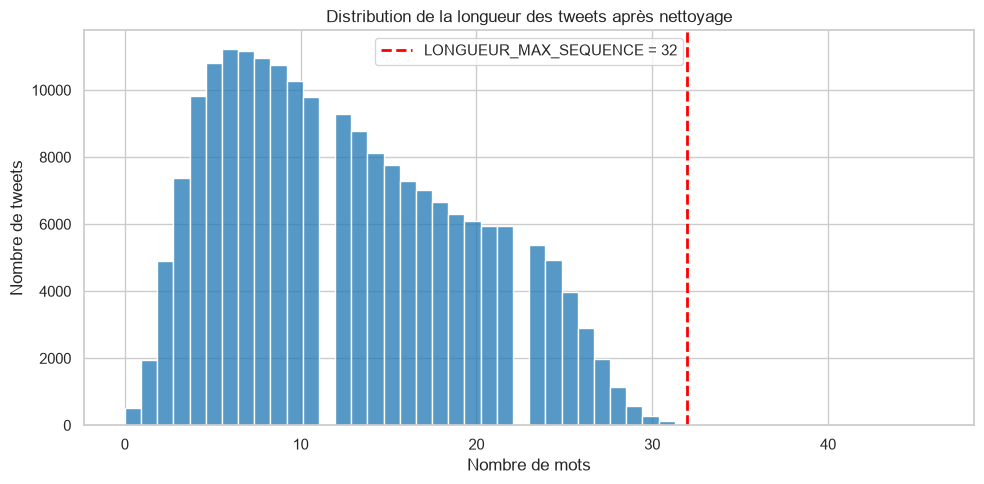

In [10]:
axe = sns.histplot(longueur_nettoyee, bins=50, color="#1f77b4")
axe.set_title("Distribution de la longueur des tweets après nettoyage")
axe.set_xlabel("Nombre de mots")
axe.set_ylabel("Nombre de tweets")

axe.axvline(
    config.LONGUEUR_MAX_SEQUENCE,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"LONGUEUR_MAX_SEQUENCE = {config.LONGUEUR_MAX_SEQUENCE}",
)
axe.legend()
plt.tight_layout()
plt.show()

### Ce qu'on retient

Le seuil retenu dans `src/config.py` est **32 mots**. Il couvre 99,98 % des tweets nettoyés.

Le choix se lit directement dans le tableau ci-dessus : passer de 40 à 32 mots réduit le
temps d'entraînement du réseau récurrent de **20 %**, au prix de la troncature de la fin de
15 tweets sur 100 000. C'est un échange manifestement avantageux — et c'est le genre d'arbitrage
qu'on fait sur une mesure, pas sur une intuition.

## 6. Doublons

Un point facile à négliger, aux conséquences pourtant lourdes sur le score final.

Le nettoyage supprime les liens et les mentions. Deux tweets qui différaient uniquement par
le pseudo mentionné deviennent alors **strictement identiques**. Le taux de doublons, faible
sur le texte brut, augmente donc nettement après nettoyage.

In [11]:
doublons_bruts = echantillon["texte"].duplicated().mean()
doublons_nettoyes = echantillon["texte_nettoye"].duplicated().mean()

print(f"Doublons sur le texte brut     : {doublons_bruts:.2%}")
print(f"Doublons sur le texte nettoyé  : {doublons_nettoyes:.2%}")

Doublons sur le texte brut     : 0.42%
Doublons sur le texte nettoyé  : 2.98%


In [12]:
print("Les textes nettoyés les plus répétés :\n")
print(echantillon["texte_nettoye"].value_counts().head(10).to_string())

Les textes nettoyés les plus répétés :

texte_nettoye
                                                                                   502
thanks                                                                             263
thank you                                                                          172
good morning                                                                       164
get followers a day using once you add everyone you are on the train or pay vip    161
me too                                                                              73
i am lost please help me find a good home                                           72
goodnight                                                                           65
i know                                                                              49
headache                                                                            44


### Pourquoi il faut les retirer

Deux problèmes distincts, tous deux sérieux :

**1. Une fuite entre l'entraînement et le test.** Le découpage train/test est aléatoire. Si un
même texte figure 500 fois dans le jeu de données, il se retrouvera mécaniquement des deux
côtés. Le modèle l'aura donc *déjà vu* pendant l'entraînement : au moment du test, il le
reconnaît au lieu de le comprendre. Le score mesuré devient optimiste, et le modèle paraît
meilleur qu'il ne le sera en production, où il ne rencontrera que des tweets inédits.

**2. Du spam de robots.** La liste ci-dessus le montre : on y trouve un message publicitaire
automatique republié des centaines de fois. Ce n'est pas du langage naturel, et le laisser
apprendre au modèle n'a aucun intérêt.

**Décision retenue : déduplication sur le texte nettoyé, en conservant la première
occurrence.** On perd environ 5 % des lignes — sans aucune importance avec 1,6 million de
tweets — et l'on gagne une évaluation honnête. C'est ce que fait `preparer_donnees()`
en section 8.

## 7. Effet du nettoyage et vocabulaire des classes

### 7.1 Ce que fait concrètement le nettoyage

On visualise ici, sur des exemples réels, le travail de `src/preprocessing.py` : suppression
des liens et des mentions, décodage des entités HTML, réduction des lettres répétées, retrait
de la ponctuation.

La colonne « sans mots vides » montre l'étape supplémentaire réservée au modèle classique. On
vérifie au passage le point le plus important du prétraitement : **les négations survivent**.

In [13]:
exemples = echantillon.sample(8, random_state=config.GRAINE_ALEATOIRE)

comparaison = pd.DataFrame({
    "Brut": exemples["texte"],
    "Nettoyé": exemples["texte_nettoye"],
    "Sans mots vides": exemples["texte_nettoye"].apply(retirer_mots_vides),
})

comparaison.reset_index(drop=True)

,Brut,Nettoyé,Sans mots vides
0,@McFLYFan_Katie listening to wonderful music. I'd like to have holidays now. xx,listening to wonderful music i'd like to have holidays now xx,listening wonderful music i'd like holidays xx
1,is watching angels and demons &lt;3 for free at http://FreeTheaters.com.,is watching angels and demons for free at,watching angels demons free
2,spending time with my baby girl...before she goes off to college.,spending time with my baby girl before she goes off to college,spending time baby girl goes college
3,I know you all too well,i know you all too well,know too
4,"@Burnt_feet hahaha cheers! I won't forget that in the exam now! I love how me, you and @sopho_suave have these chats...",hahaha cheers i won't forget that in the exam now i love how me you and have these chats before history exams,hahaha cheers won't forget exam love chats history exams
5,"@TomineeeHarket night nights..you will be just fine, dont worry...oh shoot, i should really sleep too",night nights you will be just fine dont worry oh shoot i should really sleep too,night nights fine dont worry oh shoot really sleep too
6,@biz But a great day,but a great day,but great day
7,FML jeanette mccurdy from iCarly is almost 3 months older than me,fml jeanette mccurdy from icarly is almost months older than me,fml jeanette mccurdy icarly almost months older


In [14]:
# Vérification ciblée du traitement de la négation.
cas_de_test = [
    "@AirParadis the flight was NOT good at all!!! #disappointed http://t.co/xyz",
    "Best crew ever, sooooo friendly &amp; helpful :)",
]

for texte in cas_de_test:
    print(f"Brut            : {texte}")
    print(f"Nettoyé         : {nettoyer_tweet(texte)}")
    print(f"Sans mots vides : {retirer_mots_vides(nettoyer_tweet(texte))}")
    print("-" * 100)

Brut            : @AirParadis the flight was NOT good at all!!! #disappointed http://t.co/xyz
Nettoyé         : the flight was not good at all disappointed
Sans mots vides : flight not good disappointed
----------------------------------------------------------------------------------------------------
Brut            : Best crew ever, sooooo friendly &amp; helpful :)
Nettoyé         : best crew ever soo friendly and helpful
Sans mots vides : best crew ever soo friendly helpful
----------------------------------------------------------------------------------------------------


### 7.2 Le signal existe-t-il ?

Question préalable indispensable : **les deux classes emploient-elles un vocabulaire
différent ?**

Si elles utilisaient exactement les mêmes mots, une approche par sac de mots serait condamnée
d'avance et il faudrait passer directement aux modèles contextuels.

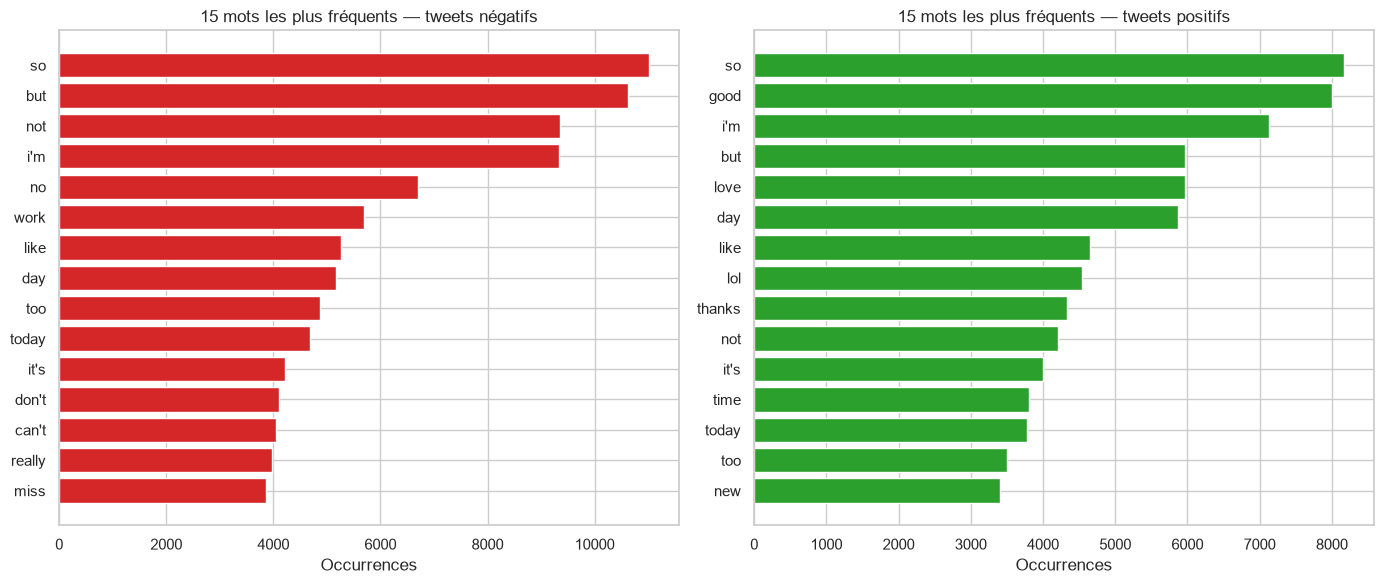

In [15]:
compteurs = {}
for valeur_label, nom_classe in [(0, "Négatif"), (1, "Positif")]:
    textes = echantillon.loc[echantillon["label"] == valeur_label, "texte_nettoye"]
    mots = " ".join(textes.apply(retirer_mots_vides)).split()
    compteurs[nom_classe] = Counter(mots)

figure, axes = plt.subplots(1, 2, figsize=(14, 6))

for axe, (nom_classe, couleur) in zip(axes, [("Négatif", "#d62728"), ("Positif", "#2ca02c")]):
    plus_frequents = compteurs[nom_classe].most_common(15)
    mots = [mot for mot, _ in plus_frequents][::-1]
    effectifs = [effectif for _, effectif in plus_frequents][::-1]

    axe.barh(mots, effectifs, color=couleur)
    axe.set_title(f"15 mots les plus fréquents — tweets {nom_classe.lower()}s")
    axe.set_xlabel("Occurrences")

plt.tight_layout()
plt.show()

In [16]:
# Mots les plus DISCRIMINANTS : présents dans une classe et rares dans l'autre.
# Le rapport des fréquences est bien plus parlant que la fréquence brute, car
# les mots très courants ("day", "work") arrivent en tête des DEUX classes et
# n'apprennent donc rien.

LISSAGE = 50          # évite la division par zéro et écarte les mots trop rares
EFFECTIF_MINIMAL = 500  # un mot vu 3 fois donnerait un rapport ininterprétable

frequences_negatives = compteurs["Négatif"]
frequences_positives = compteurs["Positif"]

scores = {
    mot: (frequences_positives[mot] + LISSAGE) / (frequences_negatives[mot] + LISSAGE)
    for mot in set(frequences_negatives) | set(frequences_positives)
    if frequences_positives[mot] + frequences_negatives[mot] >= EFFECTIF_MINIMAL
}

classement = sorted(scores.items(), key=lambda couple: couple[1])

print("Mots les plus caractéristiques des tweets NÉGATIFS :")
for mot, score in classement[:15]:
    print(f"  {mot:15s} {1 / score:5.1f}x plus fréquent chez les négatifs")

print("\nMots les plus caractéristiques des tweets POSITIFS :")
for mot, score in classement[-15:][::-1]:
    print(f"  {mot:15s} {score:5.1f}x plus fréquent chez les positifs")

Mots les plus caractéristiques des tweets NÉGATIFS :
  sad              13.5x plus fréquent chez les négatifs
  hurts             8.2x plus fréquent chez les négatifs
  headache          7.5x plus fréquent chez les négatifs
  sick              7.4x plus fréquent chez les négatifs
  poor              7.1x plus fréquent chez les négatifs
  sucks             7.1x plus fréquent chez les négatifs
  ugh               6.5x plus fréquent chez les négatifs
  hate              6.1x plus fréquent chez les négatifs
  missing           6.1x plus fréquent chez les négatifs
  miss              5.1x plus fréquent chez les négatifs
  broke             4.6x plus fréquent chez les négatifs
  anymore           4.5x plus fréquent chez les négatifs
  boo               4.3x plus fréquent chez les négatifs
  lost              4.3x plus fréquent chez les négatifs
  noo               4.3x plus fréquent chez les négatifs

Mots les plus caractéristiques des tweets POSITIFS :
  welcome           8.1x plus fréquent

### Ce qu'on retient

Le vocabulaire des deux classes est **nettement différencié**. Des mots comme *sad*, *hurts*,
*sick*, *hate* d'un côté ; *welcome*, *thanks*, *awesome*, *glad* de l'autre, apparaissent
plusieurs fois plus souvent dans une classe que dans l'autre.

Le signal existe donc bel et bien dans les mots pris isolément : une approche par sac de mots
(TF-IDF) donnera un résultat correct. Elle servira de **référence de base**.

Sa limite est déjà visible en creux : cette approche ignore l'ordre des mots, donc elle ne
peut pas distinguer *« not good »* de *« good »*. C'est précisément ce que les approches 2 et
3 viendront corriger.

## 8. Production du fichier de travail

Dernière étape : appliquer à l'ensemble des 1,6 million de tweets le traitement validé
ci-dessus — nettoyage, retrait des textes devenus vides, déduplication — puis sauvegarder le
résultat.

L'opération prend environ une minute et n'est faite **qu'une seule fois**. Les notebooks
suivants rechargeront ce fichier en moins d'une seconde.

Le format retenu est **Parquet** plutôt que CSV : plus compact, beaucoup plus rapide à
relire, et il conserve les types des colonnes sans avoir à les redéclarer.

In [17]:
# forcer=True : on régénère le fichier pour appliquer la déduplication décidée
# en section 6. Sans cet argument, la fonction se contenterait de relire un
# éventuel fichier déjà présent.
donnees_preparees = preparer_donnees(forcer=True)
donnees_preparees.head()

Lecture de : training.1600000.processed.noemoticon.csv


  1 600 000 tweets charges
  Negatifs : 800 000
  Positifs : 800 000

Nettoyage des tweets en cours...


  3 752 tweets vides, retires
  78 730 doublons, retires
  1 517 518 tweets conserves



Sauvegarde : C:\Users\dwyts\Documents\PROJET7 Openclassrooms\data\processed\tweets_prepares.parquet


,texte,label,texte_nettoye
0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",0,aww that's a bummer you shoulda got david carr of third day to do it d
1,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,0,is upset that he can't update his facebook by texting it and might cry as a result school today also blah
2,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,0,i dived many times for the ball managed to save the rest go out of bounds
3,my whole body feels itchy and like its on fire,0,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",0,no it's not behaving at all i'm mad why am i here because i can't see you all over there


In [18]:
# Vérification du fichier produit : c'est la sortie de ce notebook, celle dont
# dépendent les trois notebooks de modélisation.
fichier = config.FICHIER_DONNEES_PREPAREES
taille_mo = fichier.stat().st_size / (1024 * 1024)

print(f"Fichier   : {fichier}")
print(f"Taille    : {taille_mo:.1f} Mo")
print(f"Tweets    : {formater_nombre(len(donnees_preparees))}")
print(f"Colonnes  : {list(donnees_preparees.columns)}")

print("\nAucun doublon restant :", not donnees_preparees["texte_nettoye"].duplicated().any())

print("\nÉquilibre des classes après déduplication :")
print(donnees_preparees["label"].value_counts(normalize=True).round(4).to_string())

Fichier   : C:\Users\dwyts\Documents\PROJET7 Openclassrooms\data\processed\tweets_prepares.parquet
Taille    : 148.8 Mo
Tweets    : 1 517 518
Colonnes  : ['texte', 'label', 'texte_nettoye']



Aucun doublon restant : True

Équilibre des classes après déduplication :
label
0    0.5048
1    0.4952


---

## Conclusion

| Constat | Conséquence pour la suite |
|---|---|
| 1,6 million de tweets, classes parfaitement équilibrées | L'exactitude est une métrique fiable ; le hasard est à 50 % |
| Étiquetage automatique par émoticônes, donc bruité | Un plafond de performance existe, autour de 85 % selon la littérature |
| 99,98 % des tweets nettoyés font 32 mots ou moins | `LONGUEUR_MAX_SEQUENCE = 32` : couverture quasi totale, 20 % de calcul économisé |
| ~5 % de doublons après nettoyage, dont du spam de robots | Déduplication obligatoire, sans quoi le score de test serait gonflé par une fuite |
| Vocabulaire nettement différencié entre les classes | Une approche par sac de mots donnera déjà un résultat correct |
| L'ordre des mots n'est pas exploité par le sac de mots | Justifie les approches 2 (embeddings + réseau récurrent) et 3 (BERT) |

**Fichier produit :** `data/processed/tweets_prepares.parquet`

**Étape suivante :** `02_modele_classique.ipynb`